# When does the rat think

In [129]:
import matplotlib.pyplot as plt
import datajoint as dj
import numpy as np
import pandas as pd

import spyglass.common as sgc
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock, HexMazeChoice
from spyglass_hexmaze.hex_maze_decoding import (
    HexMazeDecodedPositionHexAnnotated,
    HexMazeDecodedPositionHex,
    HexMazeJunctionDecode,
)

key = {"nwb_file_name": "Toby20250316_.nwb", "epoch": 5}
#key = {"nwb_file_name": "IM-1478_20220727_.nwb"}
display(HexMazeBlock() & key)

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,config_id maze configuration as a string,interval_list_name descriptive name of this interval list,p_a probability of reward at port A,p_b probability of reward at port B,p_c probability of reward at port C,num_trials number of trials in this block,task_type 'barrier shift' or 'probabilty shift'
Toby20250316_.nwb,5,1,"7,10,19,21,22,24,35,42,43,46",epoch5_block1,90.0,10.0,50.0,69,probability change
Toby20250316_.nwb,5,2,"7,10,19,21,22,24,35,42,43,46",epoch5_block2,50.0,90.0,10.0,69,probability change
Toby20250316_.nwb,5,3,"7,10,19,21,22,24,35,42,43,46",epoch5_block3,50.0,10.0,90.0,69,probability change


In [130]:
# keys = HexMazeJunctionDecode().fetch("KEY")

# for key in keys:
#     try:
#         df = (HexMazeJunctionDecode & key).fetch1_dataframe()
#     except Exception as e:
#         print(f"Failed for {key}: {e}")


In [131]:
# How long is a trial? How long does the rat spend running?
pokes, trial_durations = (HexMazeBlock.Trial() & key).fetch("poke_interval", "duration")

run_durs = []
for poke, dur in zip(pokes, trial_durations):
    poke_duration = poke[1]-poke[0]
    run_duration = dur - poke_duration
    #print(run_duration)
    run_durs.append(run_duration)
    
print(f"mean run duration (poke out to next poke in): {np.mean(run_durs)}")

mean run duration (poke out to next poke in): 6.262373110677011


In [145]:
# Decoded position with maze annotations (one row per time-point)
ann_df = (HexMazeJunctionDecode & key).fetch1_dataframe()
ann_df = ann_df[ann_df["hex"] != -100].copy()

# Per-trial metadata: reward outcome and poke_in time
trial_rows = (HexMazeBlock.Trial() & key).fetch(
    "block", "block_trial_num", "reward", "poke_interval", "start_port", as_dict=True
)
trial_meta_df = pd.DataFrame([
    {
        "block": r["block"],
        "block_trial_num": r["block_trial_num"],
        "reward": r["reward"],
        "poke_in": r["poke_interval"][0],
        "start_port": r["start_port"],
    }
    for r in trial_rows
])

# Merge trial metadata onto the per-time-point data.
# The annotated table already has block and block_trial_num so this is a straightforward left-join

# Save the time index first — merge() resets it to integers
time_index = ann_df.index
ann_df = ann_df.merge(trial_meta_df, on=["block", "block_trial_num"], how="left")
ann_df.index = time_index  # restore timestamps


print(f"Total time-points (in-trial): {len(ann_df):,}")
print(f"Unique epoch trials: {ann_df['epoch_trial_num'].nunique()}")
display(ann_df)

trial_dfs = []

for trial_id, trial_df in ann_df.groupby("epoch_trial_num"):
    trial_df = trial_df.sort_index()

    # ── Skip trials with no choice point ─────────────────────────────────────
    at_choice = trial_df[trial_df["maze_portion"] == "choice_point"]
    if at_choice.empty:
        continue

    # ── Reference timepoints ──────────────────────────────────────────────────
    # Trial start: first decoded timepoint in the trial
    trial_start_time = trial_df.index[0]

    # Poke in: when the rat poked into the reward port at the end of this trial
    poke_in_time = trial_df["poke_in"].iloc[0]

    # Choice point: first timepoint the rat is on a critical choice hex
    choice_time = at_choice.index[0]

    # Chosen section: first timepoint the rat enters the chosen arm
    # NaN for trials where the rat never reaches the chosen arm in the decoded data
    at_chosen = trial_df[trial_df["maze_portion"] == "chosen"]
    chosen_entry_time = at_chosen.index[0] if not at_chosen.empty else np.nan

    trial_df = trial_df.copy()
    trial_df["time_rel_trial_start"] = trial_df.index - trial_start_time
    trial_df["time_rel_poke_in"] = trial_df.index - poke_in_time
    trial_df["time_rel_choice"] = trial_df.index - choice_time
    trial_df["time_rel_chosen_section"] = trial_df.index - chosen_entry_time
    trial_df["epoch_trial_num"] = trial_id
    trial_dfs.append(trial_df)

aligned = pd.concat(trial_dfs)
print(f"Trials included: {aligned['epoch_trial_num'].nunique()}")


Total time-points (in-trial): 1,094,112
Unique epoch trials: 207


,position_x,position_y,orientation,velocity_x,velocity_y,speed,hex,decode_position_x,decode_position_y,decode_hex,...,nearest_junction,hexes_from_junction,junction_entry_hex,junction_left_exit,junction_right_exit,rat_junction_direction,decode_junction_direction,reward,poke_in,start_port
time,,,,,,,,,,,,,,,,,,,,,
1.742166e+09,120.795000,124.758750,-0.209795,28.648173,-36.537920,46.429919,16,120.142139,124.982745,16,...,-100,-100,-100,-100,-100,None,None,0,1.742166e+09,None
1.742166e+09,120.900000,124.665000,-0.220591,28.806096,-36.751129,46.695146,16,120.142139,123.010810,16,...,-100,-100,-100,-100,-100,None,None,0,1.742166e+09,None
1.742166e+09,121.005000,124.571250,-0.231501,28.957577,-36.960734,46.953564,16,118.143562,123.010810,16,...,-100,-100,-100,-100,-100,None,None,0,1.742166e+09,None
1.742166e+09,121.110000,124.477500,-0.242526,29.102554,-37.166633,47.205055,16,118.143562,121.038875,16,...,-100,-100,-100,-100,-100,None,None,0,1.742166e+09,None
1.742166e+09,121.215000,124.383750,-0.253663,29.240969,-37.368726,47.449510,16,118.143562,121.038875,16,...,-100,-100,-100,-100,-100,None,None,0,1.742166e+09,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.742168e+09,179.994118,144.565882,2.356194,-3.616115,2.174822,4.219732,1,164.110842,144.702097,4,...,-100,-100,-100,-100,-100,None,None,1,1.742168e+09,C
1.742168e+09,179.995294,144.564706,2.356194,-3.707687,2.245016,4.334402,1,164.110842,144.702097,4,...,-100,-100,-100,-100,-100,None,None,1,1.742168e+09,C
1.742168e+09,179.996471,144.563529,2.356194,-3.800815,2.315794,4.450741,1,162.112265,142.730162,4,...,-100,-100,-100,-100,-100,None,None,1,1.742168e+09,C


Trials included: 206


In [133]:
aligned.columns

Index(['position_x', 'position_y', 'orientation', 'velocity_x', 'velocity_y',
       'speed', 'hex', 'decode_position_x', 'decode_position_y', 'decode_hex',
       'decode_distance', 'decode_hex_distance', 'hpd_thresh', 'spatial_cov',
       'block', 'block_trial_num', 'epoch_trial_num', 'hex_type',
       'decode_hex_type', 'maze_portion', 'decode_maze_portion',
       'hexes_from_start', 'hexes_from_end', 'hexes_from_unchosen',
       'hexes_from_choice', 'decode_hexes_from_start', 'decode_hexes_from_end',
       'decode_hexes_from_unchosen', 'decode_hexes_from_choice',
       'nearest_junction', 'hexes_from_junction', 'junction_entry_hex',
       'junction_left_exit', 'junction_right_exit', 'rat_junction_direction',
       'decode_junction_direction', 'reward', 'poke_in',
       'time_rel_trial_start', 'time_rel_poke_in', 'time_rel_choice',
       'time_rel_chosen_section'],
      dtype='object')

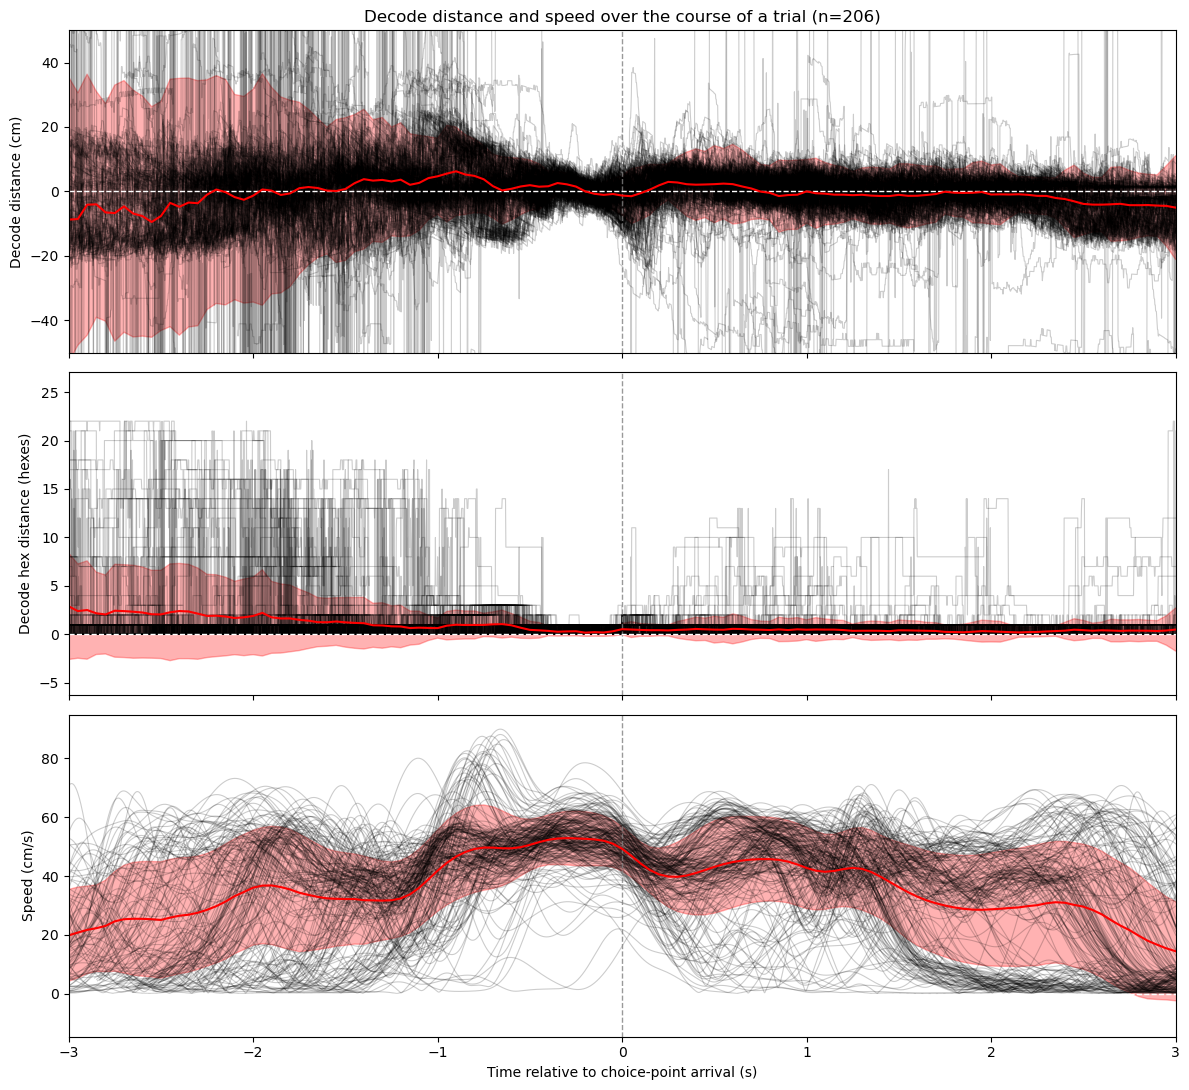

In [141]:
# Relative to choice point entry
fig, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for trial_id, t_df in aligned.groupby("epoch_trial_num"):
    ax_top.plot(t_df["time_rel_choice"], t_df["decode_distance"], color="k", alpha=0.2, linewidth=0.8)
    ax_mid.plot(t_df["time_rel_choice"], t_df["decode_hex_distance"], color="k", alpha=0.2, linewidth=0.8)
    ax_bot.plot(t_df["time_rel_choice"], t_df["speed"], color="k", alpha=0.2, linewidth=0.8)

for ax in (ax_top, ax_mid, ax_bot):
    ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8)
    ax.axhline(0, color="w", linestyle="--", linewidth=1)
    
# Mean and std across trials
bin_size = 0.05  # 50ms bins
aligned["time_bin"] = (aligned["time_rel_choice"] / bin_size).round() * bin_size
for col, ax in [("decode_distance", ax_top), ("decode_hex_distance", ax_mid), ("speed", ax_bot)]:
    grouped = aligned.groupby("time_bin")[col]
    mean = grouped.mean()
    std = grouped.std()
    ax.plot(mean.index, mean, color="r", linewidth=1.5)
    ax.fill_between(mean.index, mean - std, mean + std, color="r", alpha=0.3)

ax_top.set_title(f"Decode distance and speed over the course of a trial (n={aligned['epoch_trial_num'].nunique()})")
ax_top.set_ylim((-50, 50))
ax_top.set_ylabel("Decode distance (cm)")
ax_mid.set_ylabel("Decode hex distance (hexes)")
ax_bot.set_ylabel("Speed (cm/s)")
ax_bot.set_xlabel("Time relative to choice-point arrival (s)")

plt.xlim((-3, 3))
plt.tight_layout()
plt.show()

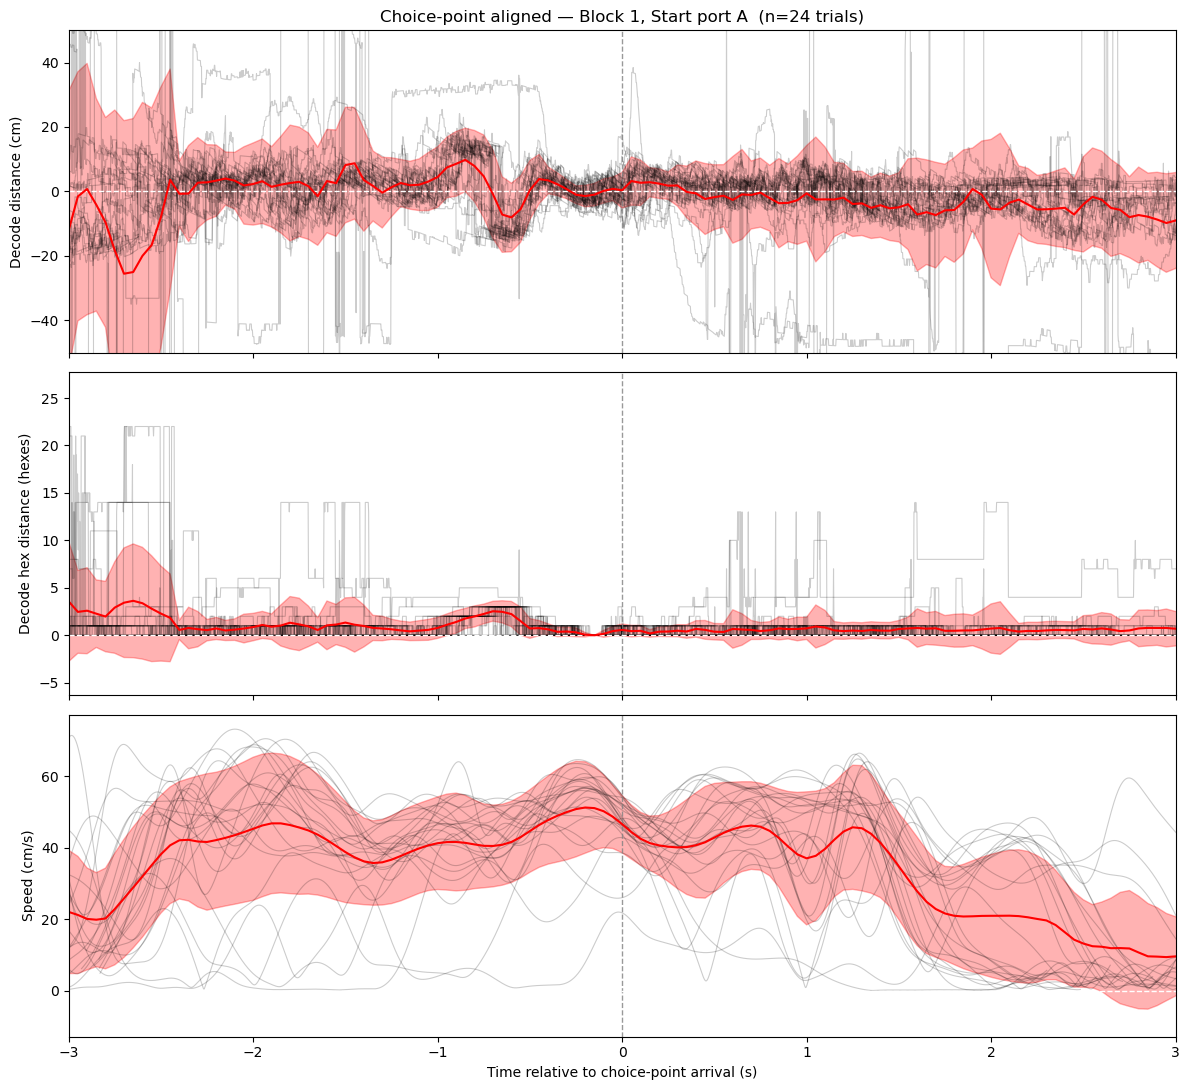

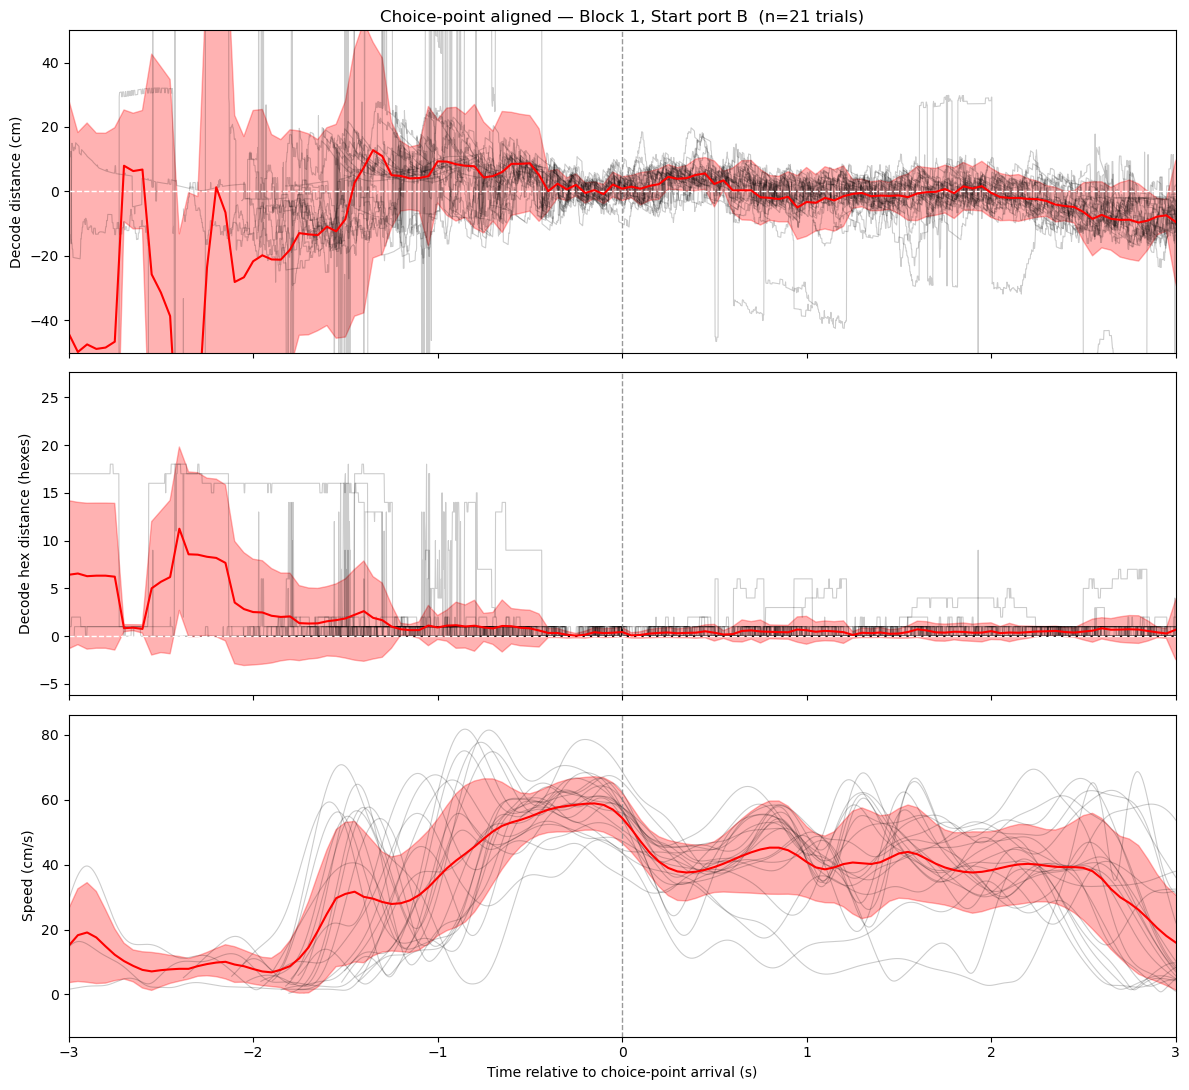

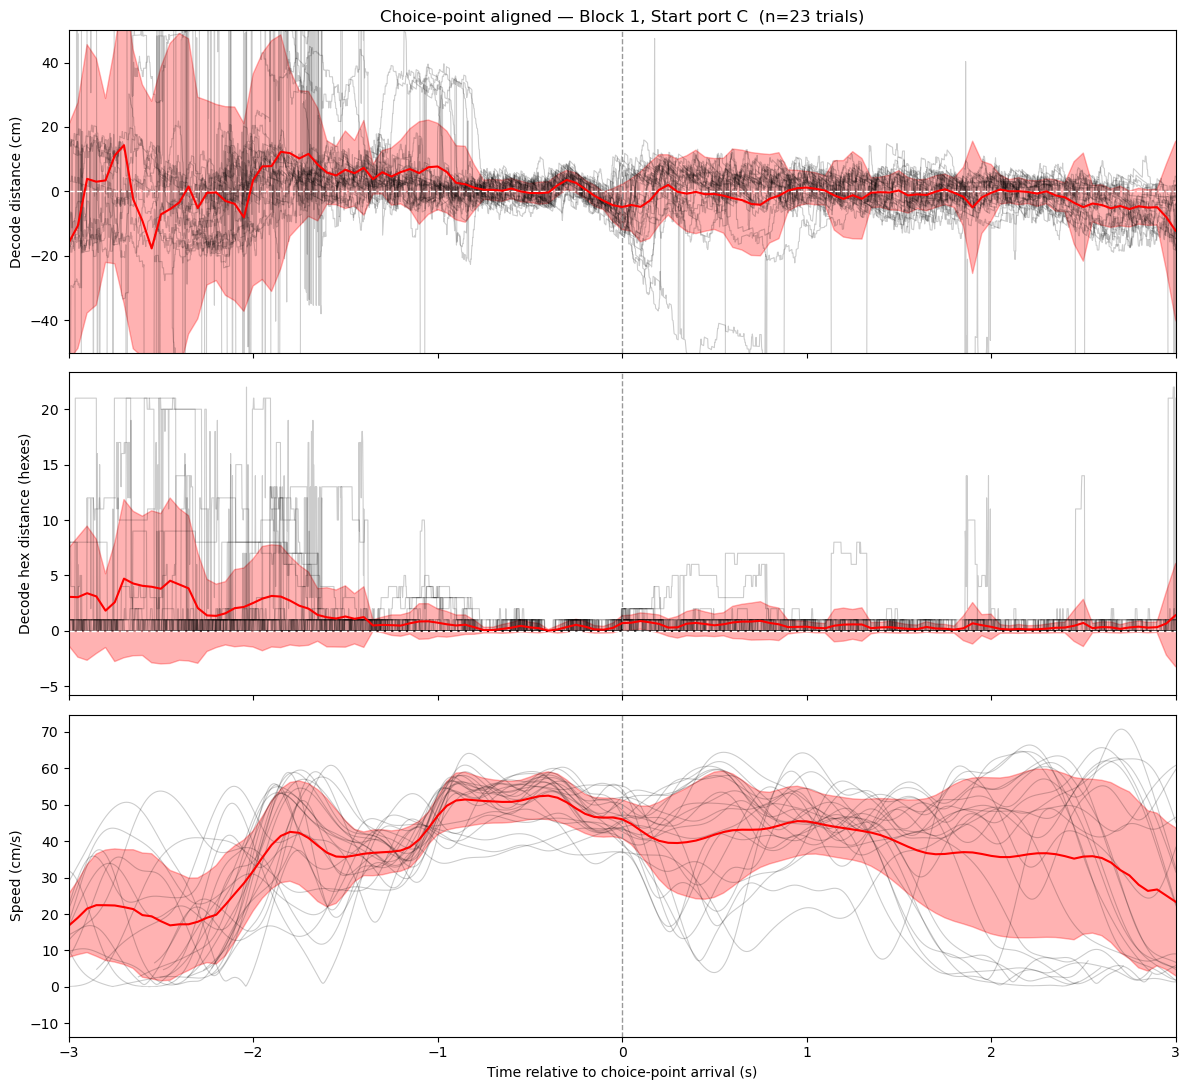

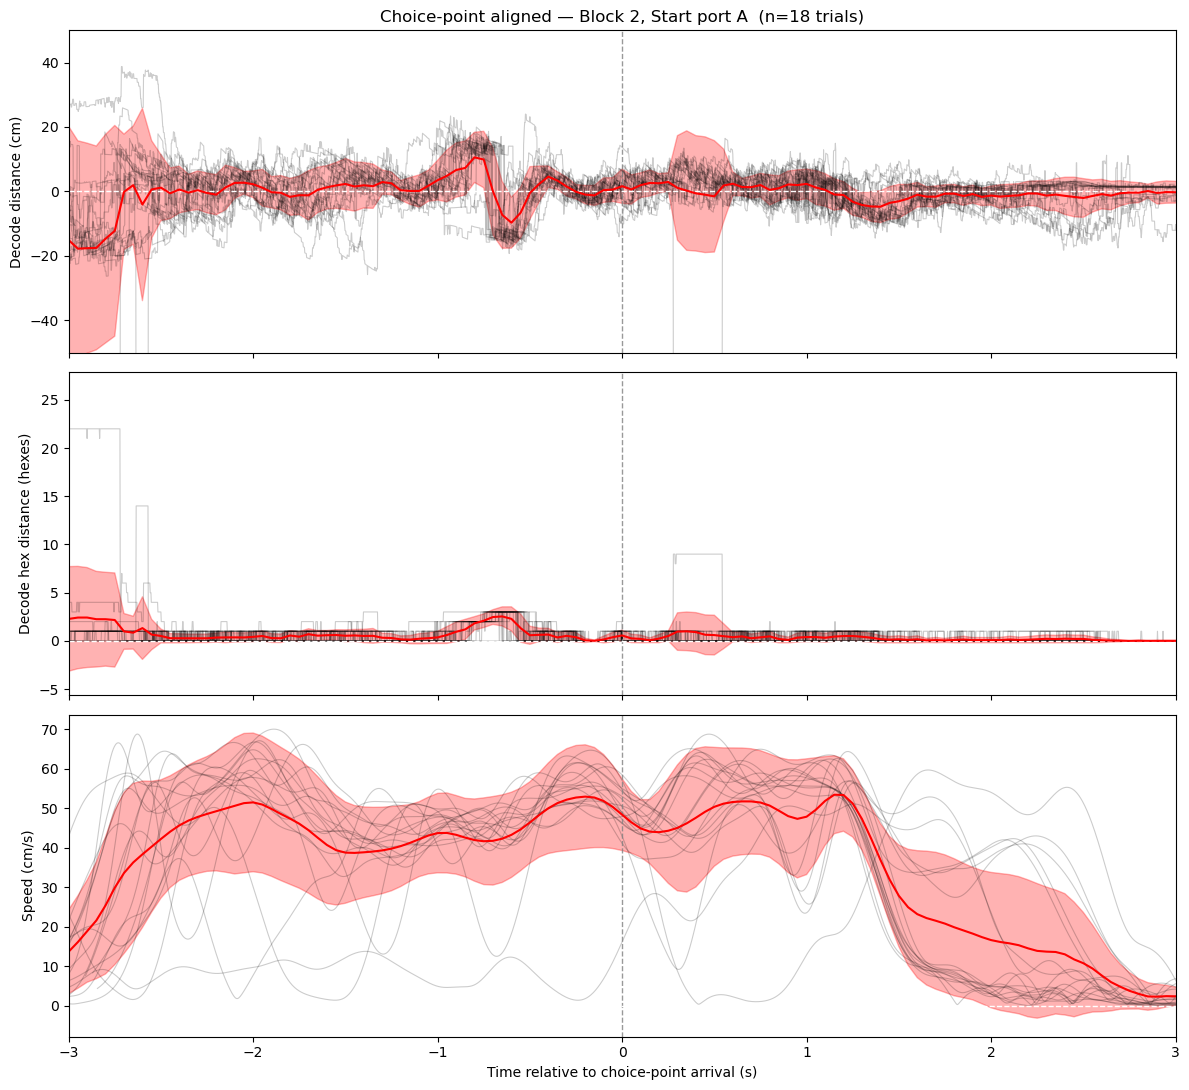

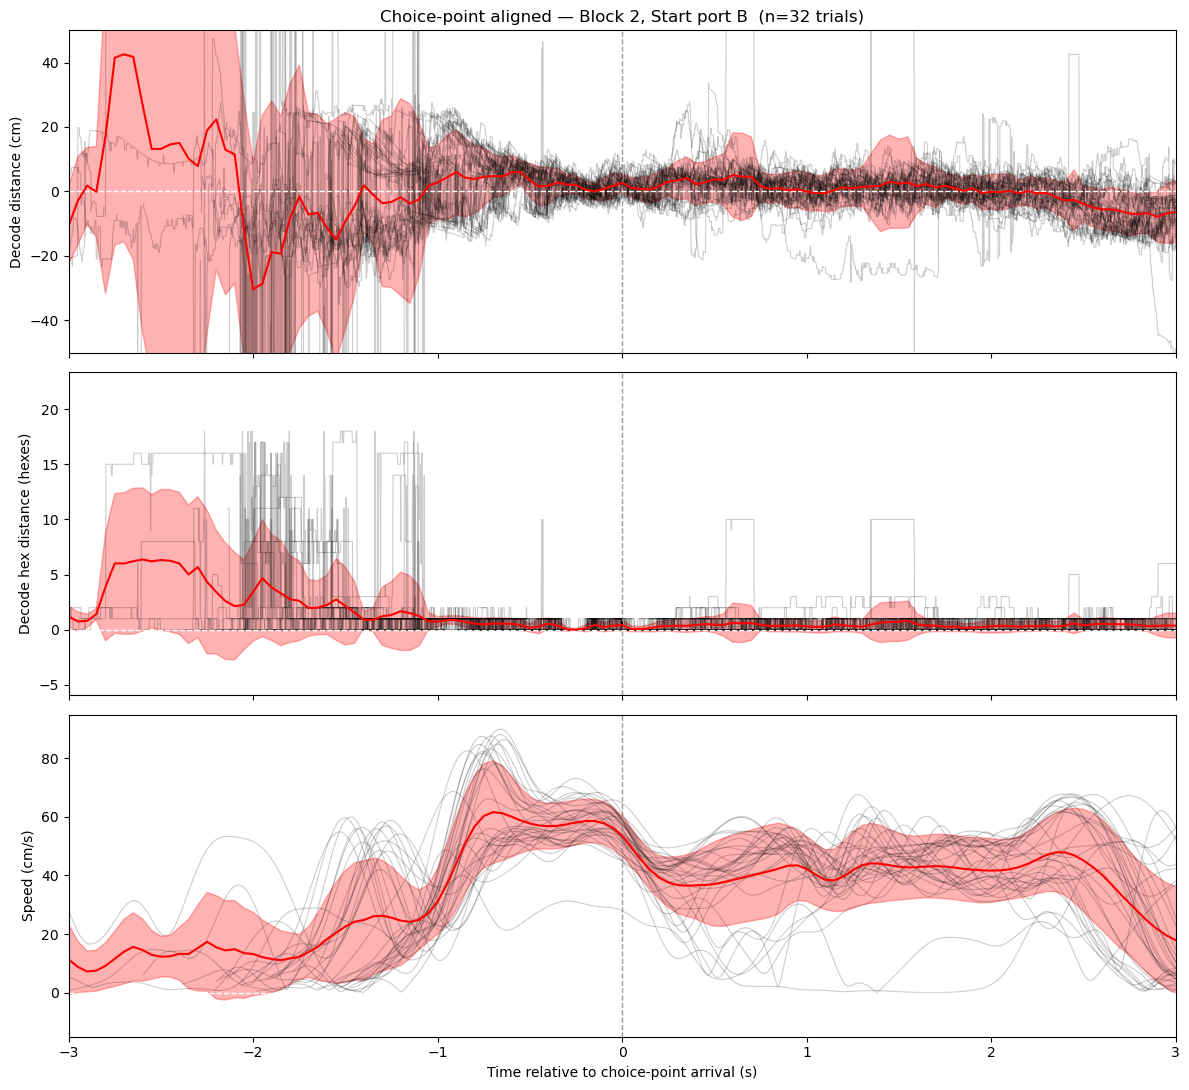

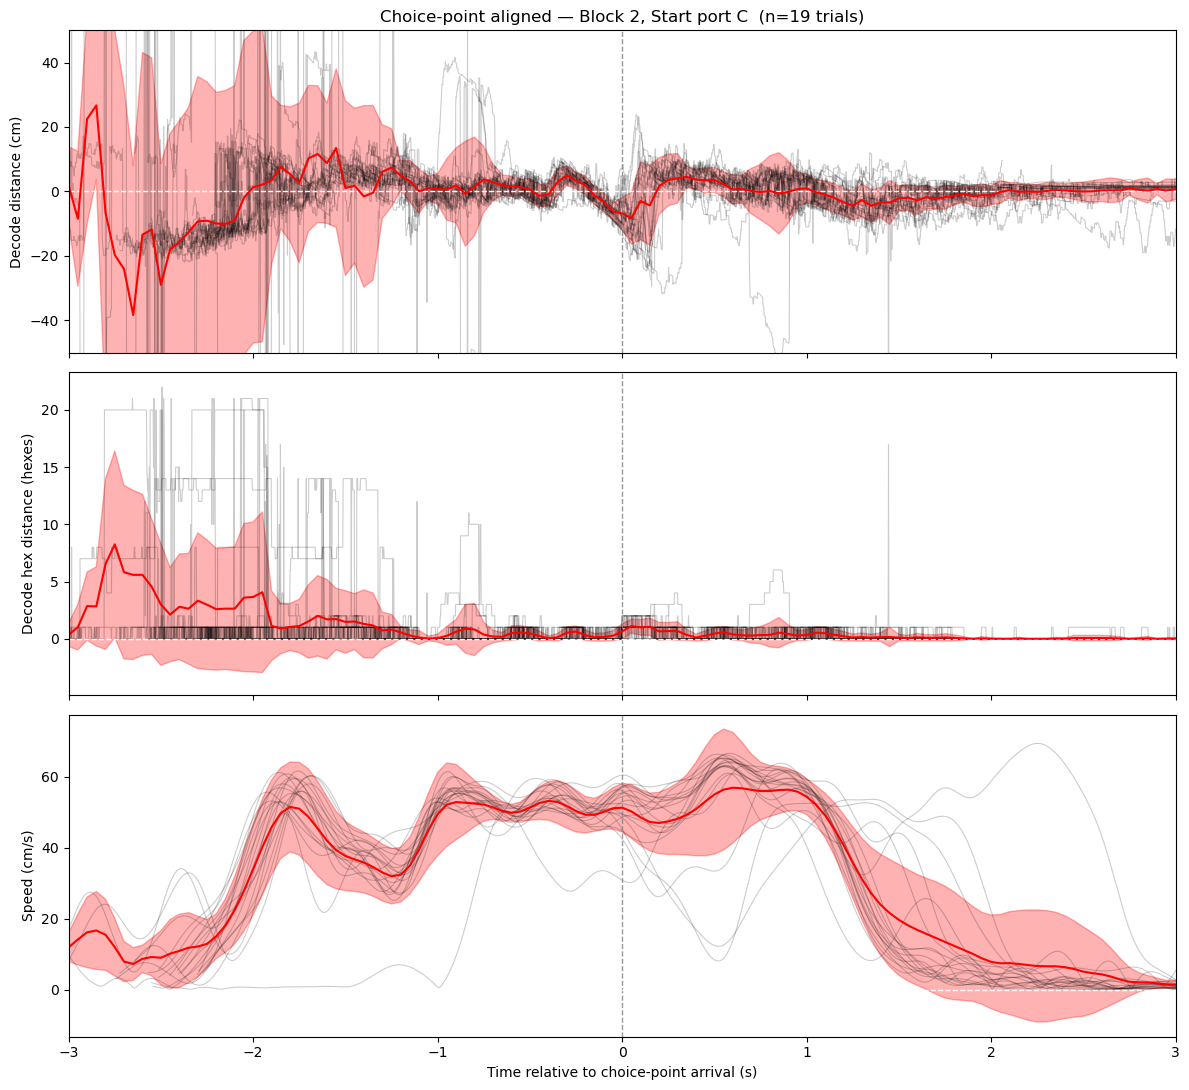

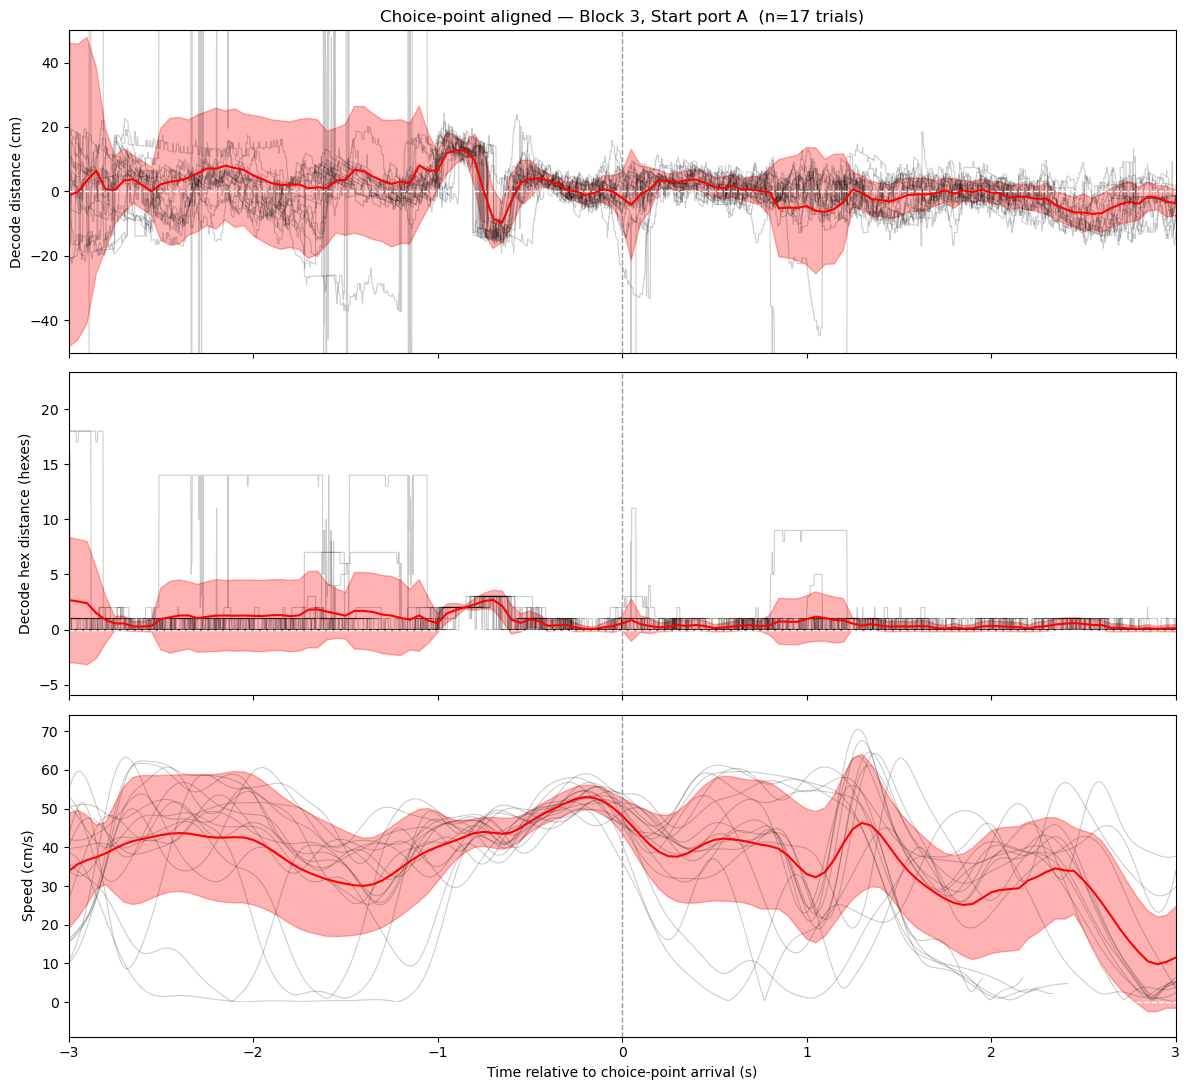

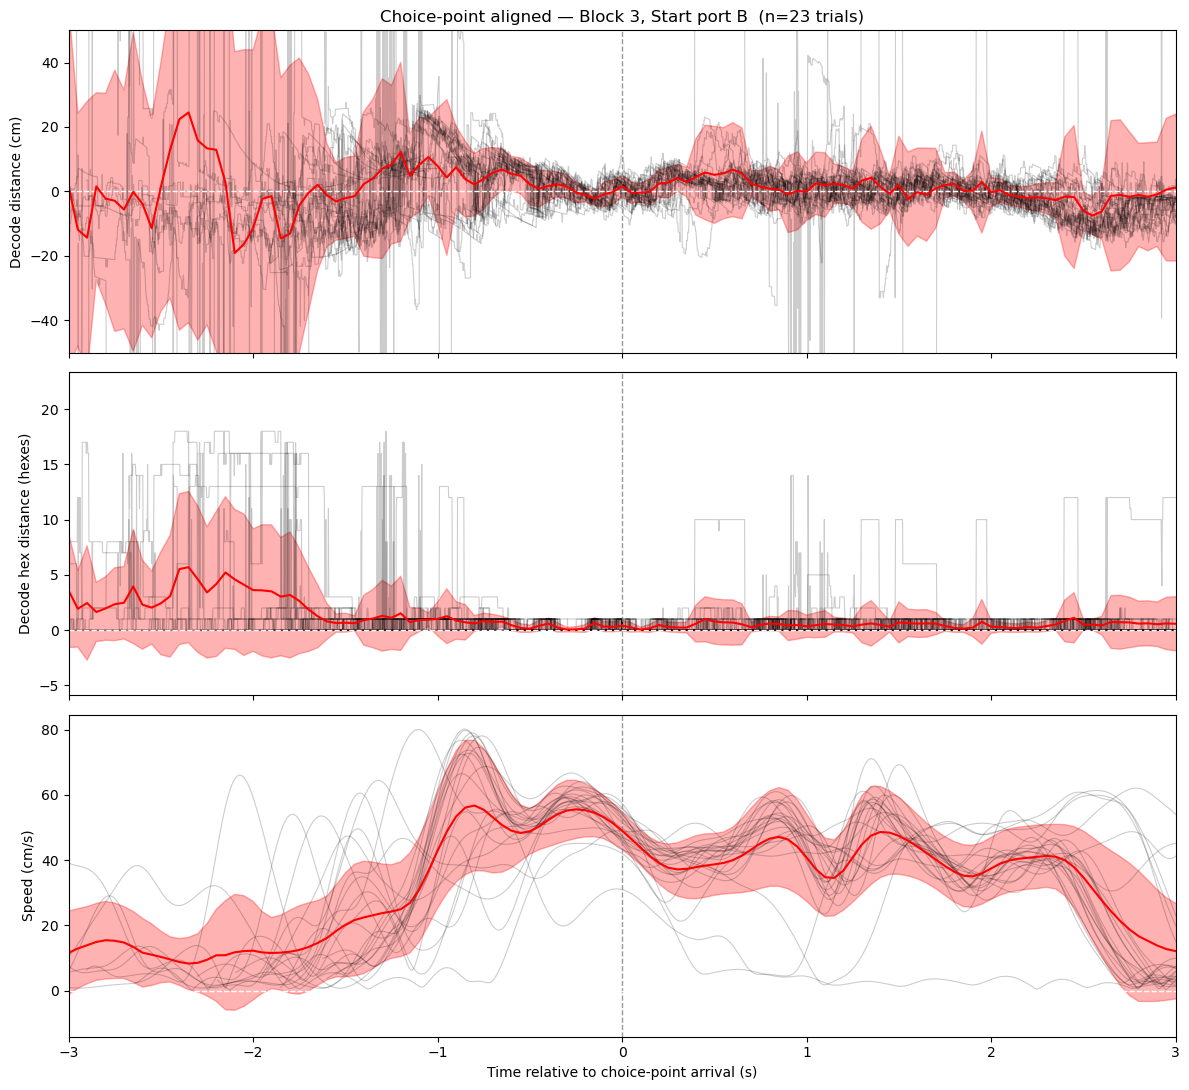

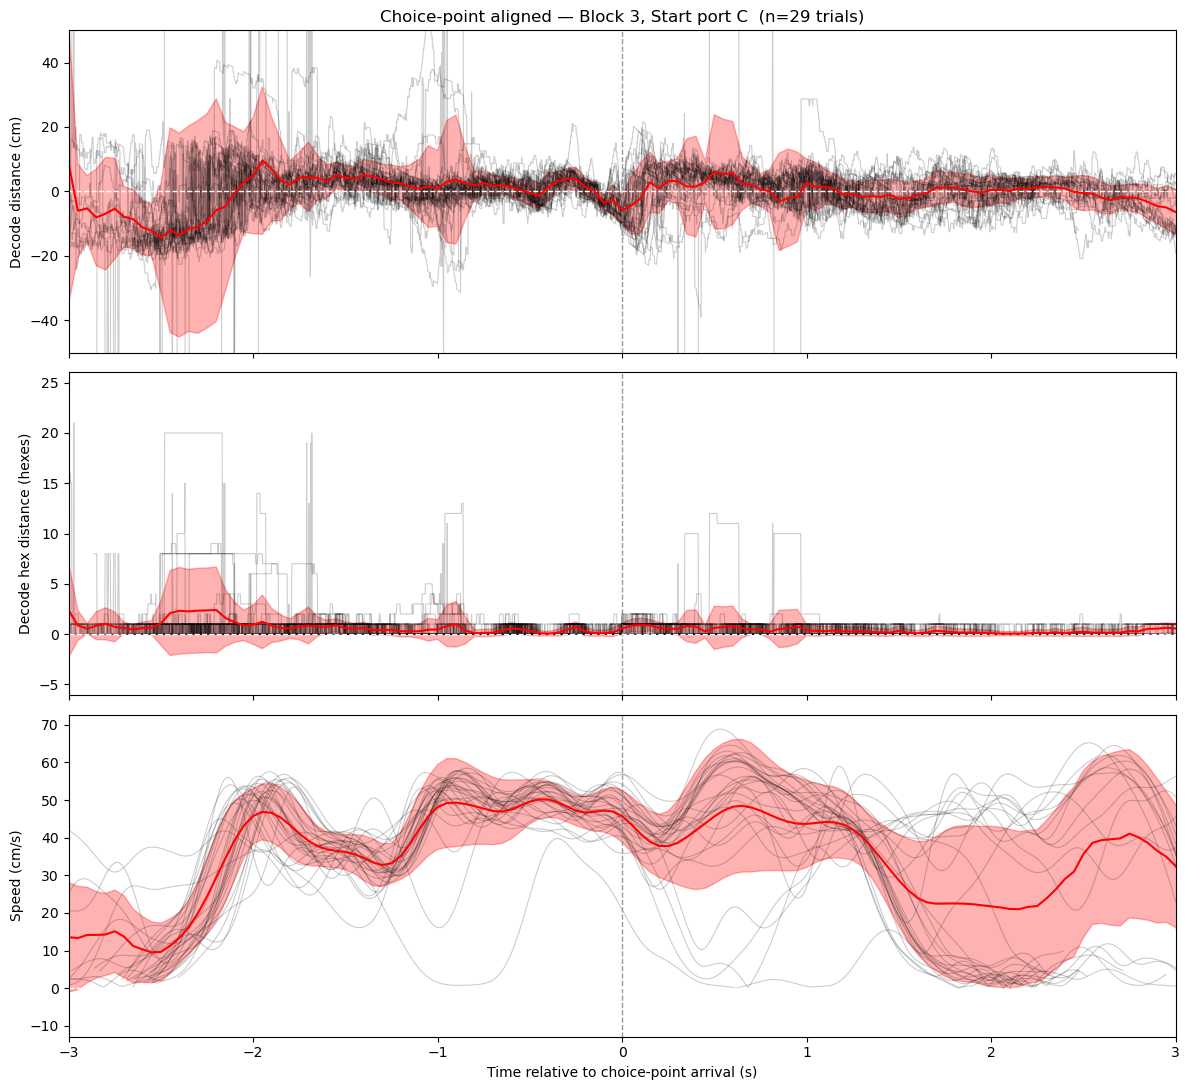

In [146]:
# Relative to choice point entry — split by block and start port
bin_size = 0.05  # 50ms bins

for (block_num, sp), subset in aligned.groupby(["block", "start_port"]):
    subset = subset.copy()
    subset["time_bin"] = (subset["time_rel_choice"] / bin_size).round() * bin_size

    fig, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

    # Individual trials in light gray
    for trial_id, t_df in subset.groupby("epoch_trial_num"):
        ax_top.plot(t_df["time_rel_choice"], t_df["decode_distance"], color="k", alpha=0.2, linewidth=0.8)
        ax_mid.plot(t_df["time_rel_choice"], t_df["decode_hex_distance"], color="k", alpha=0.2, linewidth=0.8)
        ax_bot.plot(t_df["time_rel_choice"], t_df["speed"], color="k", alpha=0.2, linewidth=0.8)

    for ax in (ax_top, ax_mid, ax_bot):
        ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8)
        ax.axhline(0, color="w", linestyle="--", linewidth=1)

    # Mean ± std in red
    for col, ax in [("decode_distance", ax_top), ("decode_hex_distance", ax_mid), ("speed", ax_bot)]:
        grouped = subset.groupby("time_bin")[col]
        mean = grouped.mean()
        std = grouped.std()
        ax.plot(mean.index, mean, color="r", linewidth=1.5)
        ax.fill_between(mean.index, mean - std, mean + std, color="r", alpha=0.3)

    ax_top.set_title(f"Choice-point aligned — Block {block_num}, Start port {sp}  (n={subset['epoch_trial_num'].nunique()} trials)")
    ax_top.set_ylim((-50, 50))
    ax_top.set_ylabel("Decode distance (cm)")
    ax_mid.set_ylabel("Decode hex distance (hexes)")
    ax_bot.set_ylabel("Speed (cm/s)")
    ax_bot.set_xlabel("Time relative to choice-point arrival (s)")
    plt.xlim((-3, 3))
    plt.tight_layout()
    plt.show()


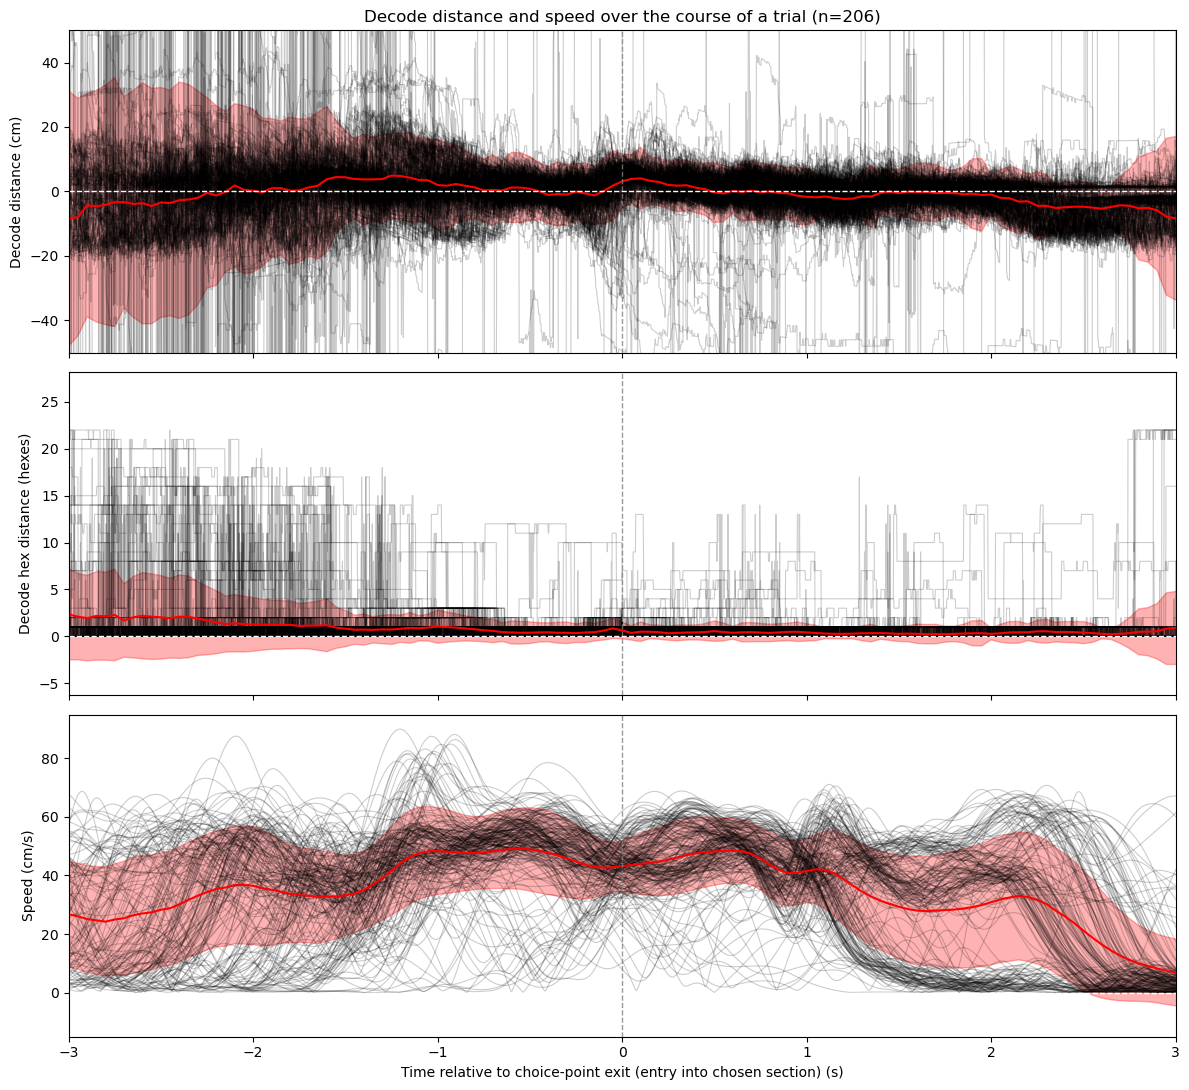

In [143]:
# Relative to choice point exit (entry into chosen section)
fig, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for trial_id, t_df in aligned.groupby("epoch_trial_num"):
    ax_top.plot(t_df["time_rel_chosen_section"], t_df["decode_distance"], color="k", alpha=0.2, linewidth=0.8)
    ax_mid.plot(t_df["time_rel_chosen_section"], t_df["decode_hex_distance"], color="k", alpha=0.2, linewidth=0.8)
    ax_bot.plot(t_df["time_rel_chosen_section"], t_df["speed"], color="k", alpha=0.2, linewidth=0.8)
    

# Mean and std across trials
bin_size = 0.05  # 50ms bins
aligned["time_bin"] = (aligned["time_rel_chosen_section"] / bin_size).round() * bin_size
for col, ax in [("decode_distance", ax_top), ("decode_hex_distance", ax_mid), ("speed", ax_bot)]:
    grouped = aligned.groupby("time_bin")[col]
    mean = grouped.mean()
    std = grouped.std()
    ax.plot(mean.index, mean, color="r", linewidth=1.5)
    ax.fill_between(mean.index, mean - std, mean + std, color="r", alpha=0.3)


for ax in (ax_top, ax_mid, ax_bot):
    ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8)
    ax.axhline(0, color="w", linestyle="--", linewidth=1)


ax_top.set_title(f"Decode distance and speed over the course of a trial (n={aligned['epoch_trial_num'].nunique()})")
ax_top.set_ylabel("Decode distance (cm)")
ax_top.set_ylim((-50, 50))
ax_mid.set_ylabel("Decode hex distance (hexes)")
ax_bot.set_ylabel("Speed (cm/s)")
ax_bot.set_xlabel("Time relative to choice-point exit (entry into chosen section) (s)")

plt.xlim((-3, 3))
plt.tight_layout()
plt.show()

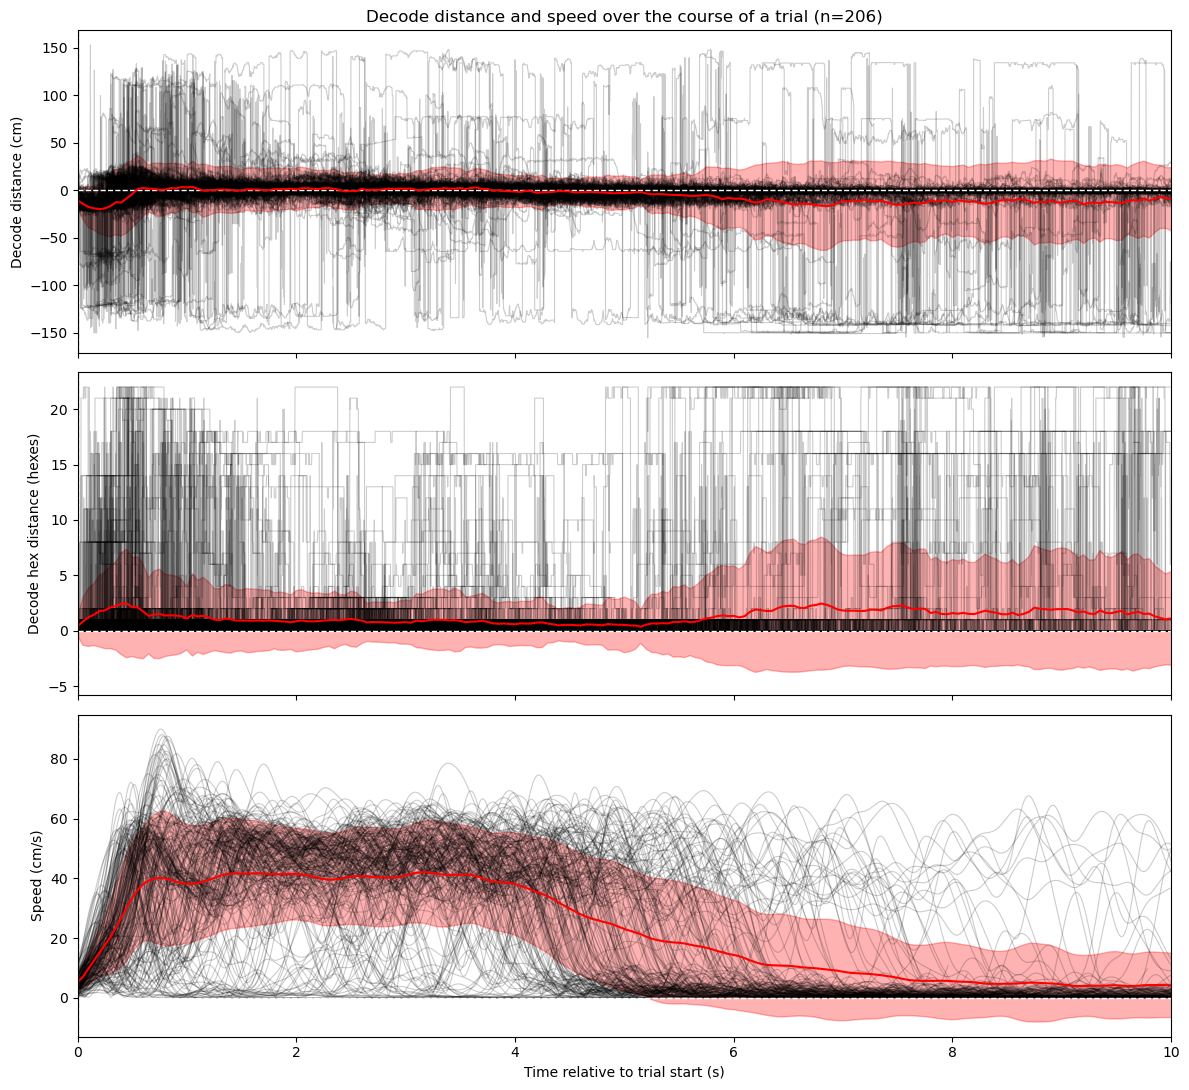

In [144]:
# Relative to trial start
fig, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for trial_id, t_df in aligned.groupby("epoch_trial_num"):
    ax_top.plot(t_df["time_rel_trial_start"], t_df["decode_distance"], color="k", alpha=0.2, linewidth=0.8)
    ax_mid.plot(t_df["time_rel_trial_start"], t_df["decode_hex_distance"], color="k", alpha=0.2, linewidth=0.8)
    ax_bot.plot(t_df["time_rel_trial_start"], t_df["speed"], color="k", alpha=0.2, linewidth=0.8)

for ax in (ax_top, ax_mid, ax_bot):
    ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8)
    ax.axhline(0, color="w", linestyle="--", linewidth=1)

# Mean and std across trials
bin_size = 0.05  # 50ms bins
aligned["time_bin"] = (aligned["time_rel_trial_start"] / bin_size).round() * bin_size
for col, ax in [("decode_distance", ax_top), ("decode_hex_distance", ax_mid), ("speed", ax_bot)]:
    grouped = aligned.groupby("time_bin")[col]
    mean = grouped.mean()
    std = grouped.std()
    ax.plot(mean.index, mean, color="r", linewidth=1.5)
    ax.fill_between(mean.index, mean - std, mean + std, color="r", alpha=0.3)

ax_top.set_title(f"Decode distance and speed over the course of a trial (n={aligned['epoch_trial_num'].nunique()})")
ax_top.set_ylabel("Decode distance (cm)")
ax_mid.set_ylabel("Decode hex distance (hexes)")
ax_bot.set_ylabel("Speed (cm/s)")
ax_bot.set_xlabel("Time relative to trial start (s)")

plt.xlim((0, 10))
plt.tight_layout()
plt.show()

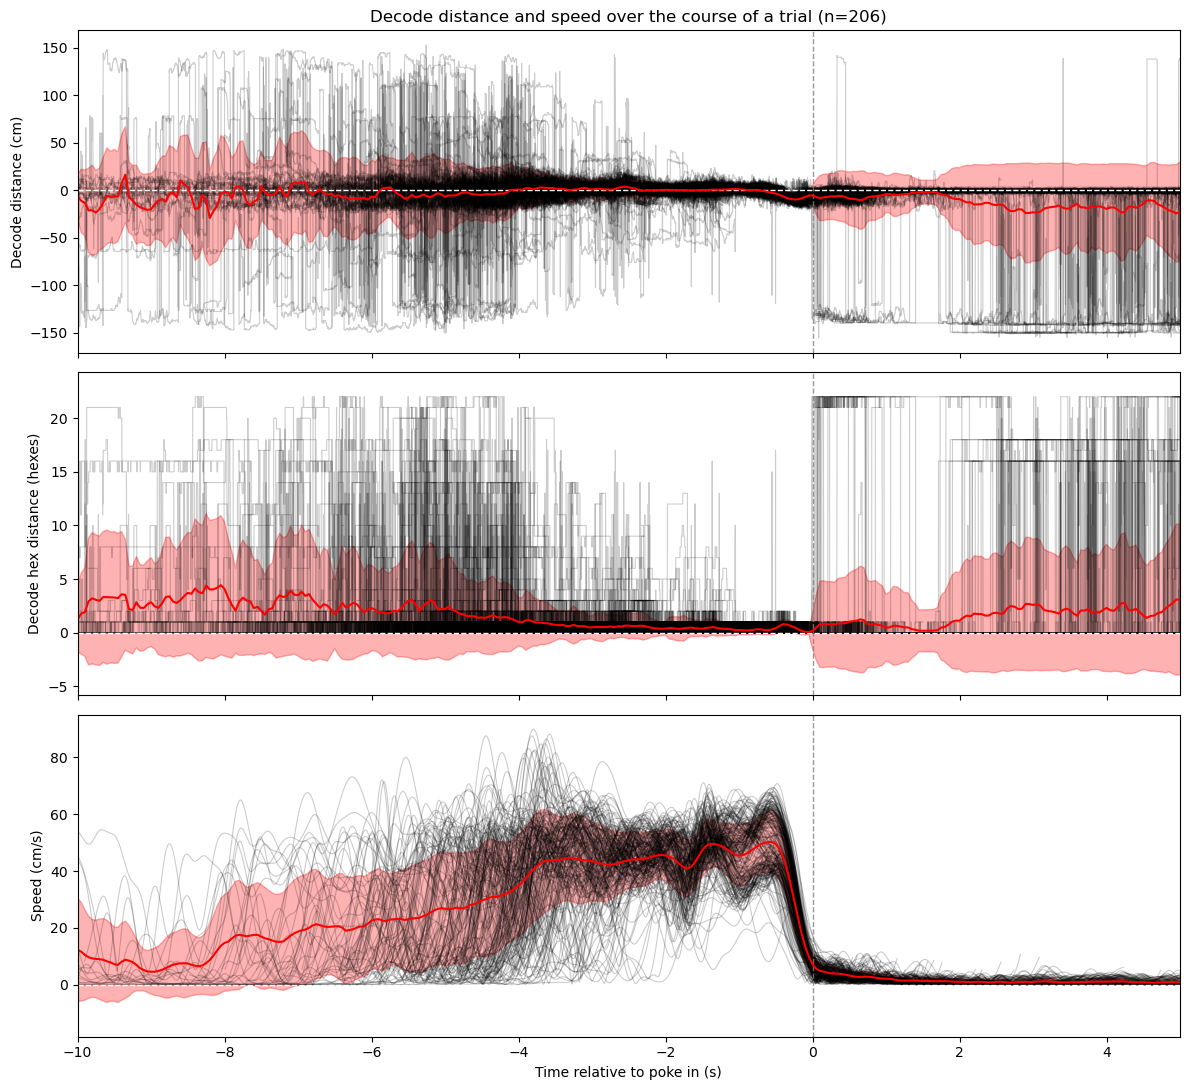

In [137]:
# Relative to poke in
fig, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for trial_id, t_df in aligned.groupby("epoch_trial_num"):
    ax_top.plot(t_df["time_rel_poke_in"], t_df["decode_distance"], color="k", alpha=0.2, linewidth=0.8)
    ax_mid.plot(t_df["time_rel_poke_in"], t_df["decode_hex_distance"], color="k", alpha=0.2, linewidth=0.8)
    ax_bot.plot(t_df["time_rel_poke_in"], t_df["speed"], color="k", alpha=0.2, linewidth=0.8)

for ax in (ax_top, ax_mid, ax_bot):
    ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8)
    ax.axhline(0, color="w", linestyle="--", linewidth=1)
    
# Mean and std across trials
bin_size = 0.05  # 50ms bins
aligned["time_bin"] = (aligned["time_rel_poke_in"] / bin_size).round() * bin_size
for col, ax in [("decode_distance", ax_top), ("decode_hex_distance", ax_mid), ("speed", ax_bot)]:
    grouped = aligned.groupby("time_bin")[col]
    mean = grouped.mean()
    std = grouped.std()
    ax.plot(mean.index, mean, color="r", linewidth=1.5)
    ax.fill_between(mean.index, mean - std, mean + std, color="r", alpha=0.3)


ax_top.set_title(f"Decode distance and speed over the course of a trial (n={aligned['epoch_trial_num'].nunique()})")
ax_top.set_ylabel("Decode distance (cm)")
ax_mid.set_ylabel("Decode hex distance (hexes)")
ax_bot.set_ylabel("Speed (cm/s)")
ax_bot.set_xlabel("Time relative to poke in (s)")

plt.xlim((-10, 5))
plt.tight_layout()
plt.show()

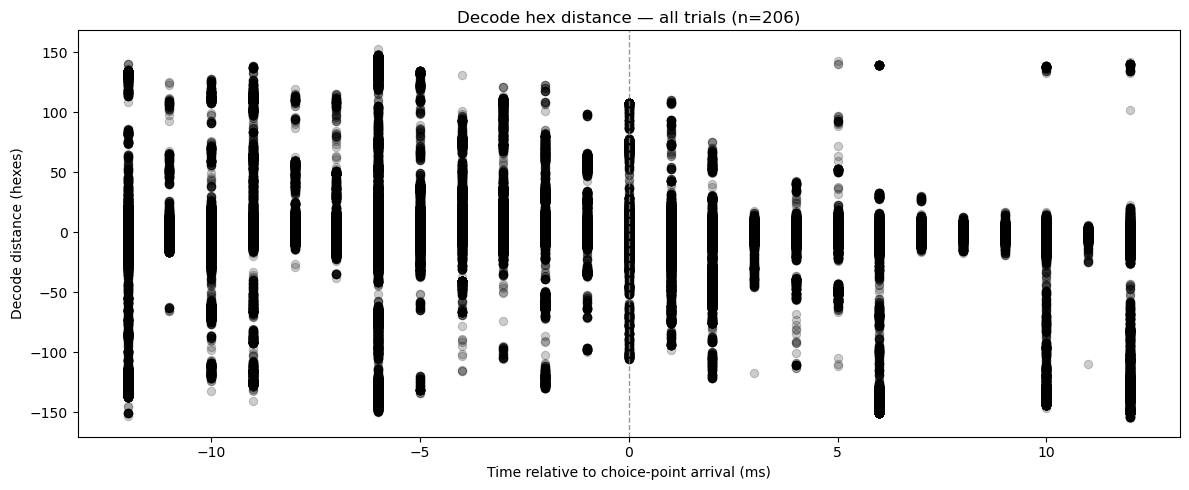

In [138]:
fig, ax = plt.subplots(figsize=(12, 5))

for trial_id, t_df in aligned.groupby("epoch_trial_num"):
    ax.scatter(t_df["hexes_from_choice"], t_df["decode_distance"], color="k", alpha=0.2, linewidth=0.8)

ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8)
ax.set_xlabel("Time relative to choice-point arrival (ms)")
ax.set_ylabel("Decode distance (hexes)")
ax.set_title(f"Decode hex distance — all trials (n={aligned['epoch_trial_num'].nunique()})")
#plt.xlim((-10000, 10000))
plt.tight_layout()
plt.show()

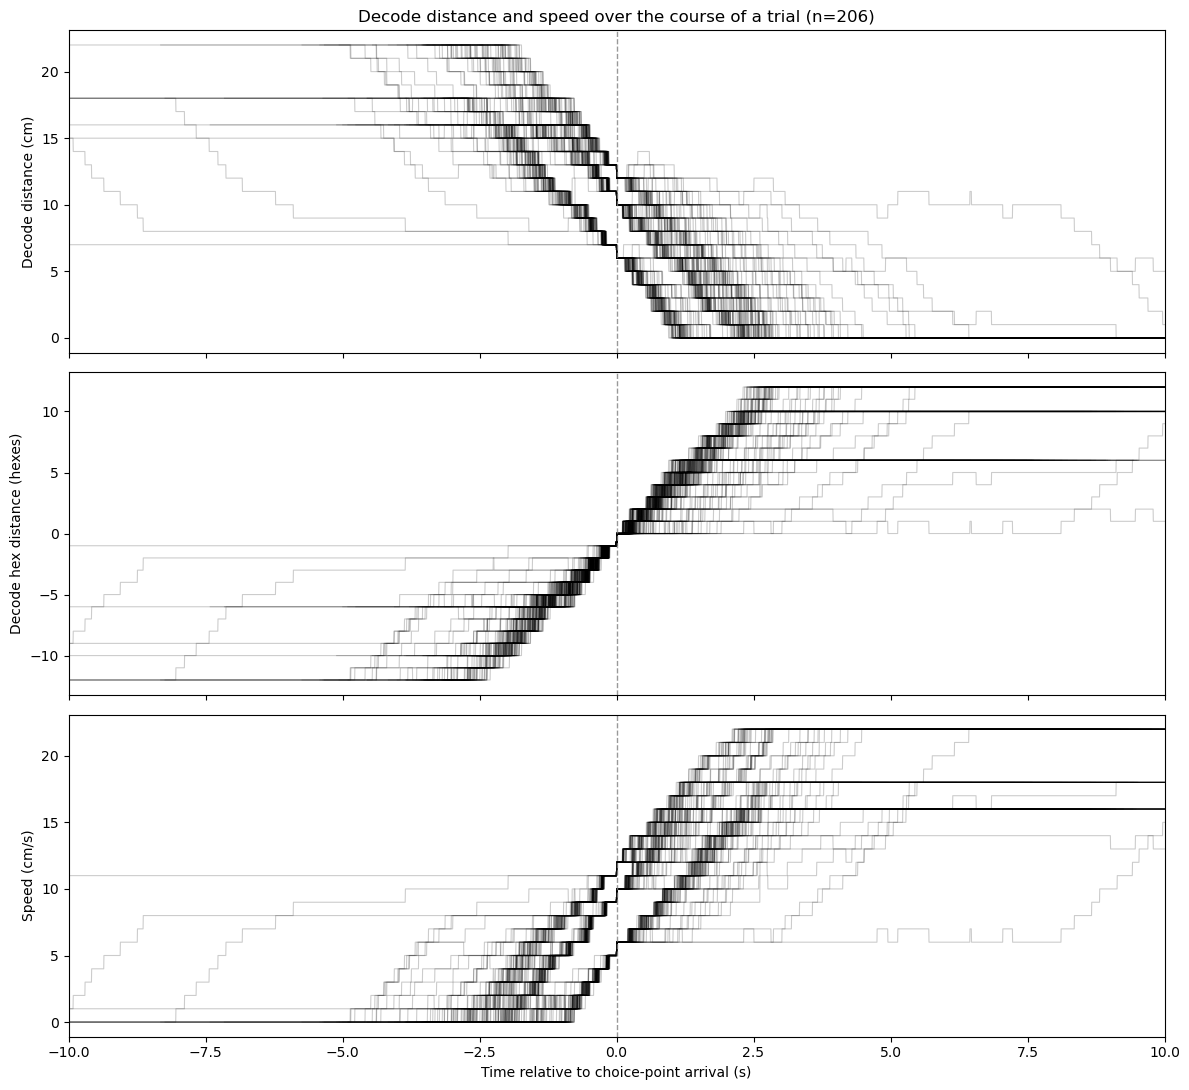

In [139]:
# Relative to choice point entry
fig, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for trial_id, t_df in aligned.groupby("epoch_trial_num"):
    ax_top.plot(t_df["time_rel_choice"], t_df["hexes_from_end"], color="k", alpha=0.2, linewidth=0.8)
    ax_mid.plot(t_df["time_rel_choice"], t_df["hexes_from_choice"], color="k", alpha=0.2, linewidth=0.8)
    ax_bot.plot(t_df["time_rel_choice"], t_df["hexes_from_start"], color="k", alpha=0.2, linewidth=0.8)

for ax in (ax_top, ax_mid, ax_bot):
    ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8)

ax_top.set_title(f"Decode distance and speed over the course of a trial (n={aligned['epoch_trial_num'].nunique()})")
ax_top.set_ylabel("Decode distance (cm)")
ax_mid.set_ylabel("Decode hex distance (hexes)")
ax_bot.set_ylabel("Speed (cm/s)")
ax_bot.set_xlabel("Time relative to choice-point arrival (s)")

plt.xlim((-10, 10))
plt.tight_layout()
plt.show()